# LSTM

## Import libraries

In [23]:
import ccxt
from datetime import datetime
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif, f_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import Huber
import matplotlib.pyplot as plt
import seaborn as sns

## Constants

In [24]:
TIMEFRAME_DICT = {
    "1m": 60 * 1000,
    "5m": 5 * 60 * 1000,
    "15m": 15 * 60 * 1000,
    "1h": 60 * 60 * 1000,
    "1d": 24 * 60 * 60 * 1000,
}

FREQ_DICT = {
    "1m": "T",
    "5m": "5T",
    "15m": "15T",
    "1h": "h",
    "1d": "D",
}

Y_OUTPUT_DICT = {
    "log_return_close": False,
    "bin_return_close": True,
    "bin_return_d2d_close": True,
}

In [25]:
CLIENT = ccxt.binance()
TICKER = "BTC/USDT"
END_DATE = CLIENT.parse8601("2026-03-31T20:00:00Z")
START_DATE = CLIENT.parse8601("2023-11-03T20:00:00Z")
TIMEFRAME = "1h"
LAGS_NUM = 240
TRAIN_TEST_SPLIT_RATIO = 0.7
HIDDEN_NEURONS_NUM = 50
EPOCHS_NUM = 100
BATCH_SIZE = 32
DROPOUT_RATE = 0.2
PATIENCE_NUM = 10
SCALER_BOOLEAN = False
OUTPUT_VALUE = 'bin_return_d2d_close'
BINARY_CLASSIFICATION = Y_OUTPUT_DICT[OUTPUT_VALUE]

## Fetching data

In [26]:
def fetch_data(client, ticker, start_date, end_date, timeframe):
    data = []
    while start_date < end_date:
        limit = 1000 if end_date - start_date >= TIMEFRAME_DICT[timeframe] * 1000 else (end_date - start_date) // (TIMEFRAME_DICT[timeframe])
        if limit <= 0:
            break
        data = data + client.fetch_ohlcv(
            ticker,
            timeframe=timeframe,
            since=start_date,
            limit=limit,
        )
        
        start_date = data[-1][0] + TIMEFRAME_DICT[timeframe] - 1 # -1 to avoid duplicates
    return data

def preprocess_data(data):
    data = pd.DataFrame(
        data,
        columns=["Date", "Open", "High", "Low", "Close", "Volume"]
    )
    # data = data.where(data["Date"] <= END_DATE + 4 * TIMEFRAME_DICT["1h"]).dropna()
    data["Date"] = pd.to_datetime(data["Date"], unit="ms")
    data = data.set_index("Date")
    return data

In [27]:
data = fetch_data(CLIENT, TICKER, START_DATE, END_DATE, TIMEFRAME)
data = preprocess_data(data)
data.head()

,Open,High,Low,Close,Volume
Date,,,,,
2023-11-03 20:00:00,34530.71,34659.66,34485.65,34593.90,1046.24789
2023-11-03 21:00:00,34593.90,34700.00,34583.86,34600.93,704.45031
2023-11-03 22:00:00,34600.94,34635.25,34563.54,34628.14,645.16337
2023-11-03 23:00:00,34628.13,34740.00,34611.38,34716.78,894.85032
2023-11-04 00:00:00,34716.78,34725.00,34653.84,34696.65,654.53035


### Verifying continuous of data

In [28]:
all_dates = pd.date_range(start=data.index.min(), end=data.index.max(), freq=FREQ_DICT[TIMEFRAME])
missing = all_dates.difference(data.index)
print(len(missing), missing)   # 0 => none missing dates

0 DatetimeIndex([], dtype='datetime64[ms]', freq='h')


## Processing data

In [29]:
data['log_return_close'] = np.log(data['Close'] / data['Close'].shift(1))
data['return_close'] = data['Close'] / data['Close'].shift(1) - 1
data['bin_return_close'] = (data['log_return_close'] > 0).astype(int)
data['bin_return_d2d_close'] = (data['log_return_close'] > data['log_return_close'].shift(1)).astype(int)

In [30]:
data = data.dropna()
data.head()

,Open,High,Low,Close,Volume,log_return_close,return_close,bin_return_close,bin_return_d2d_close
Date,,,,,,,,,
2023-11-03 21:00:00,34593.90,34700.00,34583.86,34600.93,704.45031,0.000203,0.000203,1,0
2023-11-03 22:00:00,34600.94,34635.25,34563.54,34628.14,645.16337,0.000786,0.000786,1,1
2023-11-03 23:00:00,34628.13,34740.00,34611.38,34716.78,894.85032,0.002556,0.002560,1,1
2023-11-04 00:00:00,34716.78,34725.00,34653.84,34696.65,654.53035,-0.000580,-0.000580,0,0
2023-11-04 01:00:00,34696.66,34786.68,34632.47,34768.15,724.86868,0.002059,0.002061,1,1


## Spliting data

In [31]:
X = data.drop(columns=['High', 'Low', 'Open', 'Close', 'Volume', 'bin_return_close', 'bin_return_d2d_close'])
y = data.drop(columns=['High', 'Low', 'Open', 'Close', 'Volume', 'log_return_close'])

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1-TRAIN_TEST_SPLIT_RATIO, shuffle=False)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, shuffle=False)
X_backtest, y_backtest = X_test.copy(), y_test.copy()

Overall probability of bin_return_d2d_close being the same as bin_return_close:
0.774


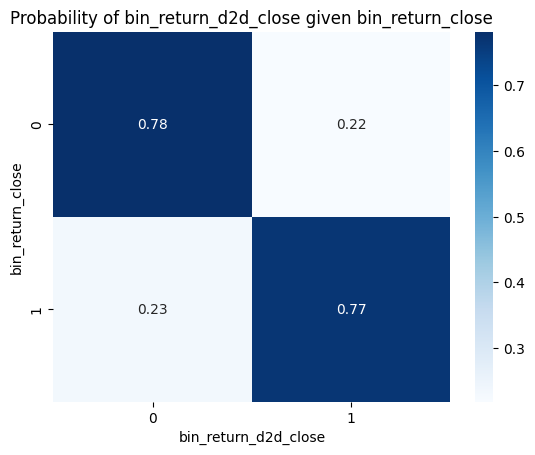

In [33]:
probs = pd.crosstab(
    y_train['bin_return_close'],
    y_train['bin_return_d2d_close'],
    normalize='index'
)
overall_prob = (y_train['bin_return_close'] == y_train['bin_return_d2d_close']).mean()
print("Overall probability of bin_return_d2d_close being the same as bin_return_close:\n{:.3f}".format(overall_prob))
sns.heatmap(probs, annot=True, fmt=".2f", cmap="Blues")
plt.title("Probability of bin_return_d2d_close given bin_return_close")
plt.xlabel("bin_return_d2d_close")
plt.ylabel("bin_return_close")
plt.show()

In [34]:
def generate_lags(X, y, lags_num, output_value, scaler_bool=False):
    X_values = X['log_return_close'].values
    y_values = y[output_value].values
    scaler = None
    if scaler_bool:
        scaler = StandardScaler()
        X_values = scaler.fit_transform(X_values.reshape(-1, 1)).flatten()
        if not BINARY_CLASSIFICATION:
            y_values = scaler.fit_transform(y_values.reshape(-1, 1)).flatten()
    X_return = []
    y_return = []
    for i in range(lags_num, len(X_values)):
        X_return.append(X_values[i-lags_num:i])
        y_return.append(y_values[i])
    X_return = np.array(X_return).reshape(-1, lags_num, 1)
    y_return = np.array(y_return).reshape(-1, 1)
    return X_return, y_return, scaler

In [35]:
X_train, y_train, scaler = generate_lags(X_train, y_train, LAGS_NUM, OUTPUT_VALUE, SCALER_BOOLEAN)
X_val, y_val, _ = generate_lags(X_val, y_val, LAGS_NUM, OUTPUT_VALUE, SCALER_BOOLEAN)
X_test, y_test, _ = generate_lags(X_test, y_test, LAGS_NUM, OUTPUT_VALUE, SCALER_BOOLEAN)

## Building and training model

In [36]:
model = Sequential()
model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
model.add(GRU(HIDDEN_NEURONS_NUM))
model.add(Dropout(DROPOUT_RATE))
if BINARY_CLASSIFICATION:
    model.add(Dense(2, activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
else:
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_absolute_error', metrics=['mae'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 50)             │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,052 (31.45 KB)

 Trainable params: 8,052 (31.45 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
if BINARY_CLASSIFICATION:
    print("Binary classification")
    model.fit(X_train, y_train, epochs=EPOCHS_NUM, batch_size=BATCH_SIZE, validation_data=(X_val, y_val), callbacks=[EarlyStopping(monitor='val_accuracy', patience=PATIENCE_NUM, restore_best_weights=True)])
else:
    print("Regression")
    model.fit(X_train, y_train, epochs=EPOCHS_NUM, batch_size=BATCH_SIZE, validation_data=(X_val, y_val), callbacks=[EarlyStopping(monitor='val_mae', patience=PATIENCE_NUM, restore_best_weights=True)])

Binary classification
Epoch 1/100


454/454 ━━━━━━━━━━━━━━━━━━━━ 57s 119ms/step - accuracy: 0.5520 - loss: 0.6903 - val_accuracy: 0.5198 - val_loss: 0.6862
Epoch 2/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 63s 139ms/step - accuracy: 0.6348 - loss: 0.6673 - val_accuracy: 0.6905 - val_loss: 0.6541
Epoch 3/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 59s 131ms/step - accuracy: 0.6993 - loss: 0.6222 - val_accuracy: 0.6949 - val_loss: 0.6151
Epoch 4/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 60s 133ms/step - accuracy: 0.7217 - loss: 0.5802 - val_accuracy: 0.7483 - val_loss: 0.5770
Epoch 5/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 64s 142ms/step - accuracy: 0.7326 - loss: 0.5546 - val_accuracy: 0.7493 - val_loss: 0.5553
Epoch 6/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 66s 145ms/step - accuracy: 0.7450 - loss: 0.5392 - val_accuracy: 0.7462 - val_loss: 0.5425
Epoch 7/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 62s 137ms/step - accuracy: 0.7414 - loss: 0.5337 - val_accuracy: 0.7456 - val_loss: 0.5349
Epoch 8/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 56s 124ms/step - accuracy: 0.7458 - loss: 0.529

## Verifying model

In [38]:
y_pred = model.predict(X_test)
if BINARY_CLASSIFICATION:
    y_pred = np.argmax(y_pred, axis=1)
else:
    if SCALER_BOOLEAN:
        y_pred = scaler.inverse_transform(y_pred.flatten().reshape(-1, 1)).flatten()
        y_test = scaler.inverse_transform(y_test.flatten().reshape(-1, 1)).flatten()

92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step


In [39]:
print(y_test.flatten()[:10])
print(y_pred.flatten()[:10])

[1 1 0 0 1 0 0 1 0 1]
[1 0 0 0 1 0 1 1 0 0]


In [40]:
if BINARY_CLASSIFICATION:
    print(classification_report(y_test.flatten(), y_pred, digits=4))
else:
    print("Regression metrics would be printed here.")
    Directional_accuracy = np.mean((y_pred > 0) == (y_test.flatten() > 0))
    print(f"Directional accuracy: {Directional_accuracy:.4f}")

              precision    recall  f1-score   support

           0     0.7432    0.7677    0.7552      1485
           1     0.7520    0.7264    0.7390      1440

    accuracy                         0.7474      2925
   macro avg     0.7476    0.7470    0.7471      2925
weighted avg     0.7475    0.7474    0.7472      2925



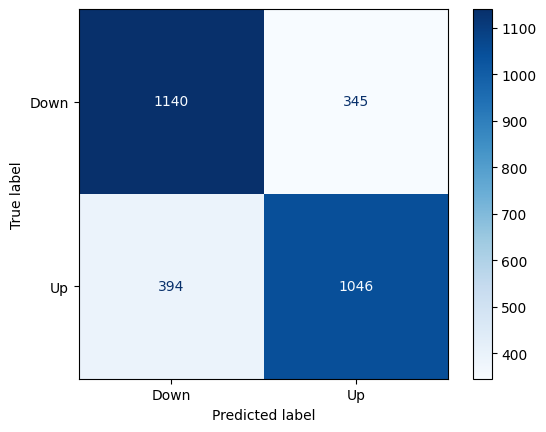

In [41]:
if BINARY_CLASSIFICATION:
    ConfusionMatrixDisplay.from_predictions(y_test.flatten(), y_pred, cmap='Blues', display_labels=["Down", "Up"])
else:
    print("Confusion matrix is not applicable for regression.")
    plt.figure(figsize=(12, 8))
    plt.plot(y_test.flatten(), label='True')
    plt.plot(y_pred.flatten()/10, label='Predicted')
    plt.legend()
    plt.show()

In [42]:
# Coverage model pred with bin_return_close
prob_coverage = overall_prob * classification_report(y_test.flatten(), y_pred, output_dict=True)['accuracy']
print("Coverage model accuracy based on bin_return_close:\n{:.3f}".format(prob_coverage))

Coverage model accuracy based on bin_return_close:
0.578


## Backtesting model

Final cash: 2150.00
Total return: 115.00%
Price direction bet accuracy: 0.5197
Strategy annualized Sharpe (risk-free=0.0%): 4.0207
Buy and hold return: -25.25%
Buy and hold annualized Sharpe: -1.5082


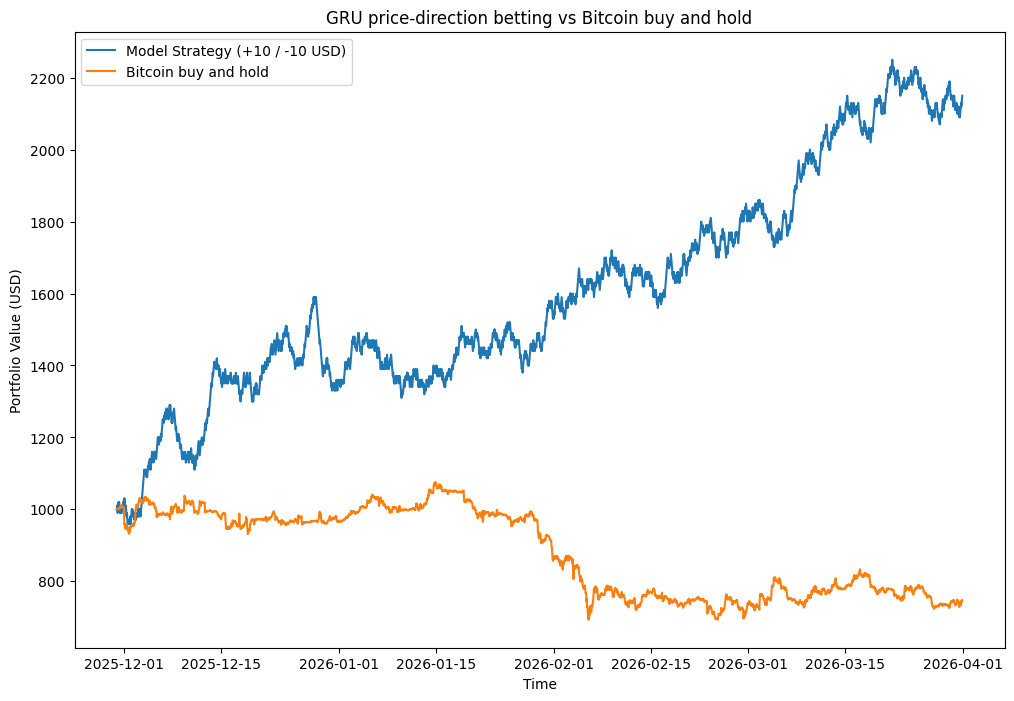

In [43]:
# Match the requested strategy: interpret predicted class 1 as UP and 0 as DOWN.
# For bin_return_d2d_close, price-direction
# betting accuracy below is therefore a different metric from its report.
# Predictions correspond to the test block after its first LAGS_NUM rows.
predictions = np.asarray(y_pred).ravel()
backtest_index = X_backtest.index[LAGS_NUM:]
if len(predictions) == 0 or len(predictions) != len(backtest_index):
    raise ValueError("Predictions must match the test samples after lag generation.")
if not np.isfinite(predictions).all():
    raise ValueError("Predictions contain non-finite values.")
if BINARY_CLASSIFICATION and not np.isin(predictions, [0, 1]).all():
    raise ValueError("Classification predictions must be labels 0 or 1.")
y_return = X_backtest.loc[backtest_index, 'return_close'].to_numpy()
signal = predictions.astype(int) if BINARY_CLASSIFICATION else (predictions > 0).astype(int)
START_CASH = 1000.0
BET_PAYOUT = 10.0
start_cash = START_CASH
cash = start_cash
movement_list = [cash]
for prediction, actual_return in zip(signal, y_return):
    if prediction == 1:
        cash += BET_PAYOUT if actual_return > 0 else -BET_PAYOUT
    else:
        cash += BET_PAYOUT if actual_return < 0 else -BET_PAYOUT
    movement_list.append(cash)
# As in the supplied example, zero price change loses for either direction.
# This fixed-stake simulation continues even if capital reaches zero.

settlement_index = backtest_index + pd.Timedelta(milliseconds=TIMEFRAME_DICT[TIMEFRAME])
curve_index = pd.DatetimeIndex([backtest_index[0]]).append(settlement_index)
strategy_curve = pd.Series(movement_list, index=curve_index, name="Model Strategy")
# Compound actual simple returns: cumsum is only an approximation to buy and hold.
buy_and_hold_curve = pd.Series(
    np.r_[start_cash, start_cash * np.cumprod(1 + y_return)],
    index=curve_index, name="Bitcoin buy and hold")

RISK_FREE_ANNUAL = 0.0
# Crypto trades 24/7: 8760 hourly periods per 365-day year.
periods_per_year = (365 * 24 * 60 * 60 * 1000) / TIMEFRAME_DICT[TIMEFRAME]

def annualized_sharpe(equity, periods_per_year, risk_free_annual=0.0):
    equity = np.asarray(equity, dtype=float)
    if (len(equity) < 3 or not np.isfinite(equity).all()
            or (equity <= 0).any()):
        return np.nan  # Percentage-return Sharpe is not reported after insolvency.
    returns = np.diff(equity) / equity[:-1]
    risk_free_per_period = np.expm1(np.log1p(risk_free_annual) / periods_per_year)
    excess_returns = returns - risk_free_per_period
    volatility = excess_returns.std(ddof=1)
    if np.isclose(volatility, 0.0):
        return np.nan
    # Conventional square-root annualization; not adjusted for autocorrelation.
    return np.sqrt(periods_per_year) * excess_returns.mean() / volatility

strategy_sharpe = annualized_sharpe(strategy_curve, periods_per_year, RISK_FREE_ANNUAL)
buy_and_hold_sharpe = annualized_sharpe(buy_and_hold_curve, periods_per_year, RISK_FREE_ANNUAL)
backtest_results = pd.DataFrame({
    "prediction": predictions,
    "predicted_direction": signal,
}, index=backtest_index)
backtest_results["price_return"] = y_return
backtest_results["pnl_usd"] = np.diff(movement_list)
backtest_results["cash"] = movement_list[1:]

print(f"Final cash: {cash:.2f}")
print(f"Total return: {(cash - start_cash) / start_cash * 100:.2f}%")
print(f"Price direction bet accuracy: {(backtest_results.pnl_usd > 0).mean():.4f}")
print(f"Strategy annualized Sharpe (risk-free={RISK_FREE_ANNUAL:.1%}): {strategy_sharpe:.4f}")
print(f"Buy and hold return: {(buy_and_hold_curve.iloc[-1] / start_cash - 1) * 100:.2f}%")
print(f"Buy and hold annualized Sharpe: {buy_and_hold_sharpe:.4f}")
if (strategy_curve <= 0).any():
    print("Strategy reached non-positive capital: Sharpe is undefined (NaN).")
plt.figure(figsize=(12, 8))
plt.plot(strategy_curve.index, strategy_curve, label="Model Strategy (+10 / -10 USD)")
plt.plot(buy_and_hold_curve.index, buy_and_hold_curve, label="Bitcoin buy and hold")
plt.xlabel("Time")
plt.ylabel("Portfolio Value (USD)")
plt.title("GRU price-direction betting vs Bitcoin buy and hold")
plt.legend()
plt.show()

In [44]:
# Backtesting is consolidated in the preceding cell (fixed +10 / -10 USD bets).
